# EDA & Preprocessing


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading & Inspection

In [2]:
df = pd.read_csv("../datasets/customers_dataset.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.shape

(2240, 22)

In [5]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

## 2. Handling Missing Values

Fill missing `Income` values with the median to avoid skew from outliers.

In [7]:
df["Income"] = df["Income"].fillna(df["Income"].median())

## 3. Feature Engineering

In [8]:
# Age from Year of Birth
df["Age"] = 2026 - df["Year_Birth"]

In [9]:
# Customer Tenure
# - Days since joining, calculated relative to the latest date in the dataset.

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

reference_date = df["Dt_Customer"].max()
df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

In [10]:
# Total Spending

df["Total_Spending"] = (
    df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"]
    + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]
)

In [11]:
# Total Children

df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [12]:
# Simplify Education Levels

df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [13]:
df["Education"] = df["Education"].replace({
    "Basic": "Undergraduate",
    "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "Postgraduate",
    "PhD": "Postgraduate"
})

In [14]:
# Simplify Marital Status

df["Living_With"] = df["Marital_Status"].replace({
    "Married": "Partner",
    "Together": "Partner",
    "Single": "Alone",
    "Divorced": "Alone",
    "Widow": "Alone",
    "Absurd": "Alone",
    "YOLO": "Alone"
})

In [15]:
# View all new columns

df[["Age", "Customer_Tenure_Days", "Total_Spending", "Total_Children", "Education", "Living_With"]].head()

,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education,Living_With
0,69,663,1617,0,Graduate,Alone
1,72,113,27,2,Graduate,Alone
2,61,312,776,0,Graduate,Partner
3,42,139,53,1,Graduate,Partner
4,45,161,422,1,Postgraduate,Partner


## 4. Dropping Unnecessary Columns

In [16]:
cols_to_drop = [
    "ID", "Year_Birth", "Marital_Status",
    "Kidhome", "Teenhome", "Dt_Customer"
]
spending_cols = [
    "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds"
]

df_clean = df.drop(columns=cols_to_drop + spending_cols)

In [17]:
df_clean.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


## 5. Outlier Detection and Removal

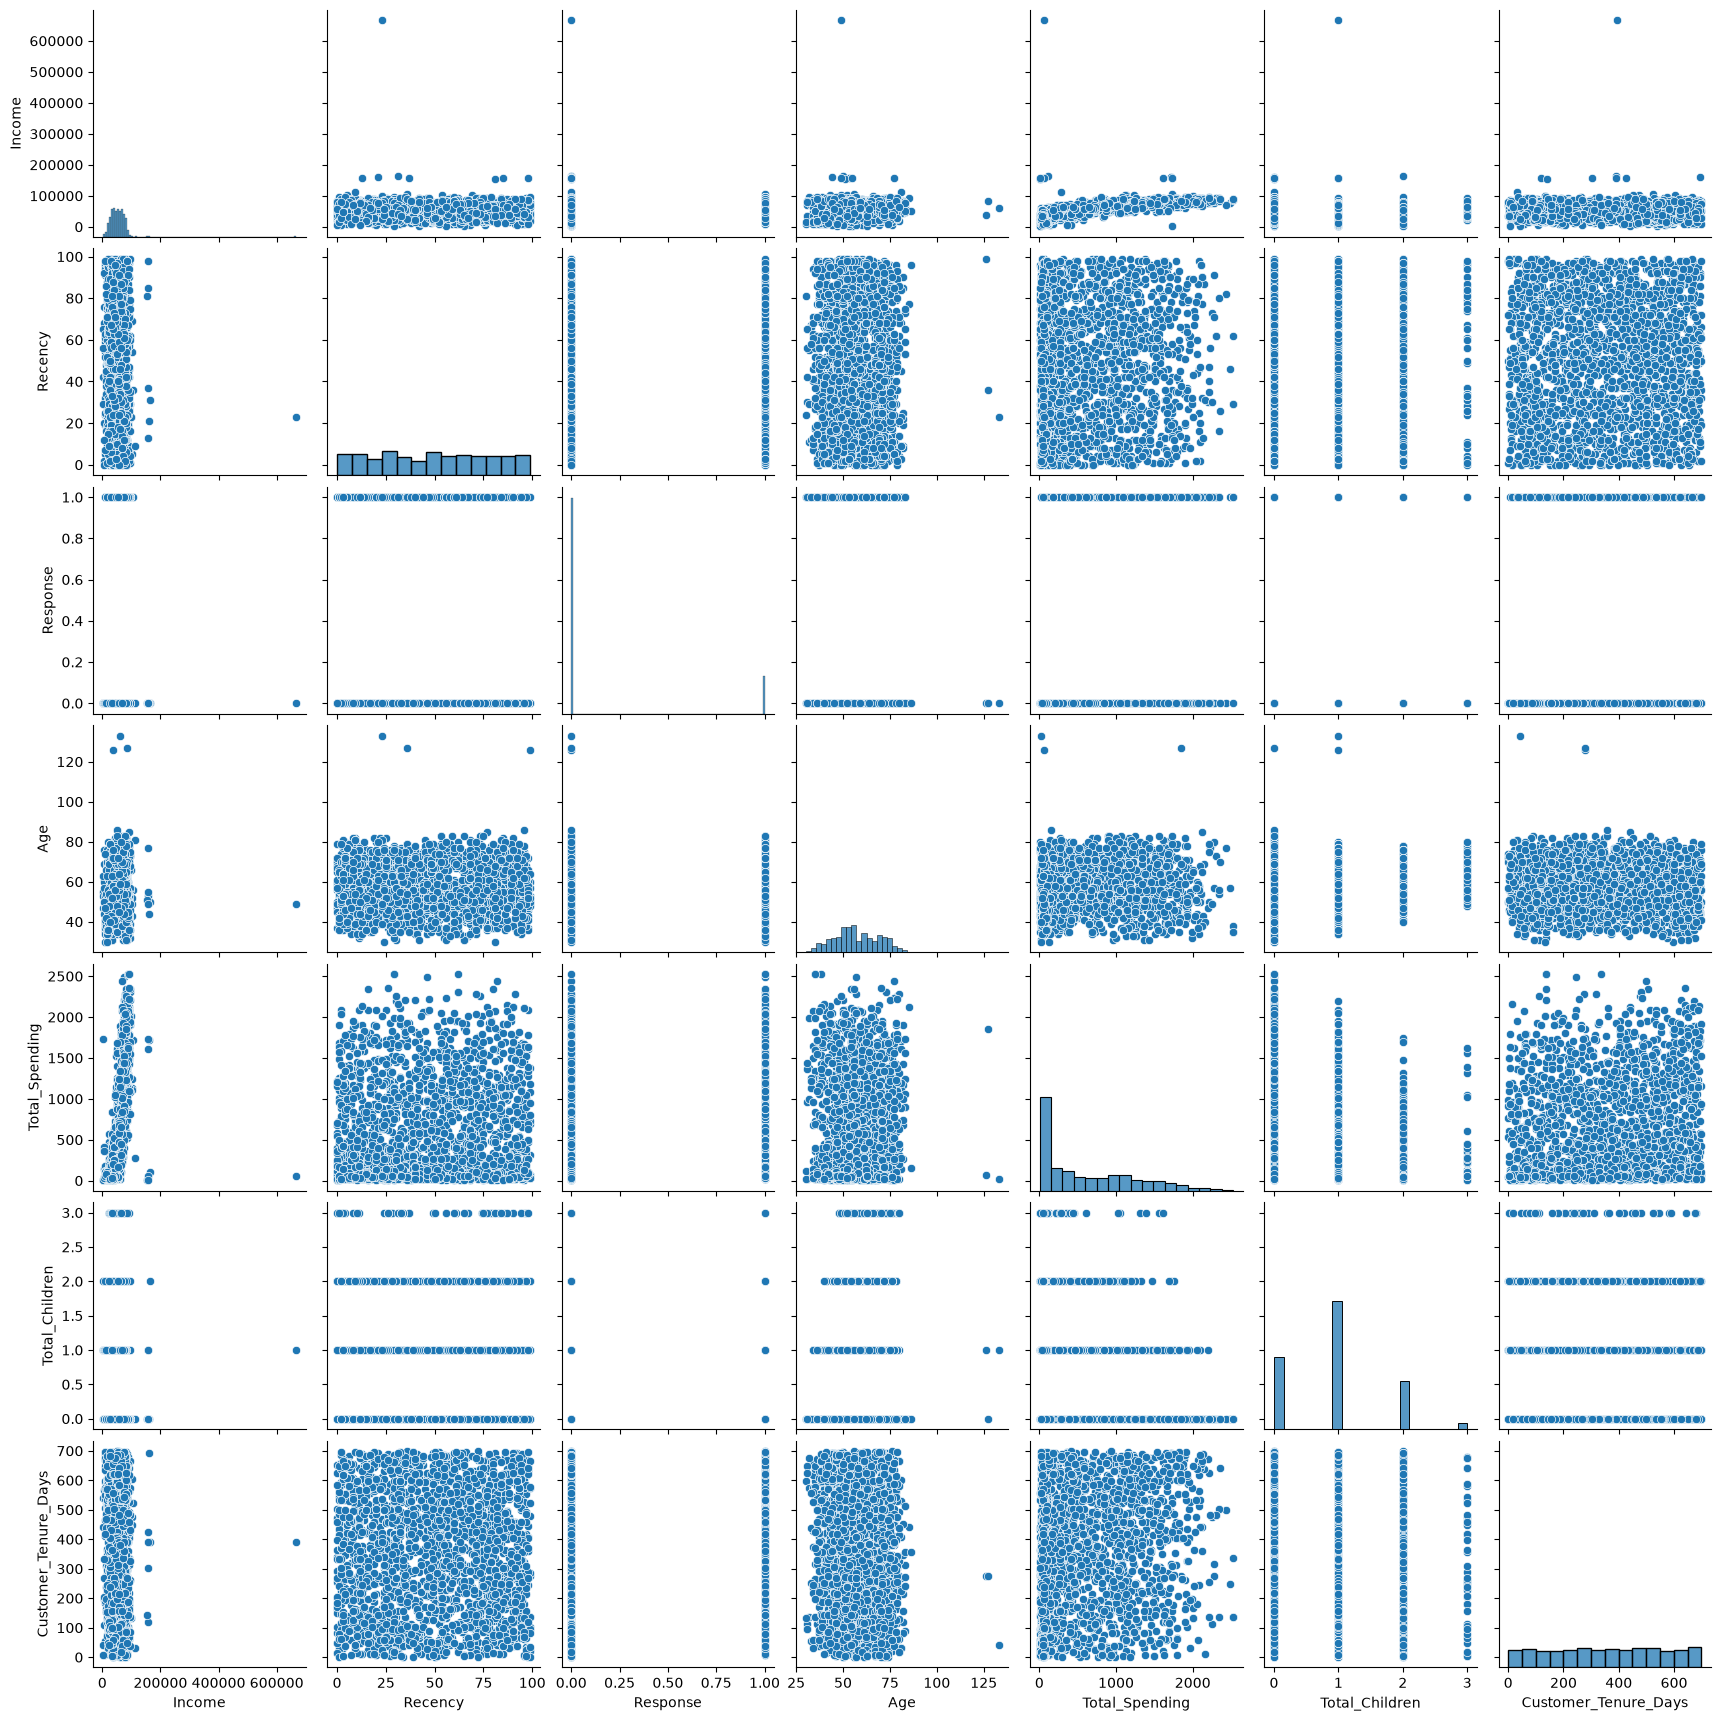

In [18]:
sns.pairplot(df_clean[[
    "Income", "Recency", "Response", "Age",
    "Total_Spending", "Total_Children", "Customer_Tenure_Days"
]])

Removing extreme outliers visible in the pairplot (Age ≥ 90 and Income ≥ 600 000).

In [19]:
print(f"Before outlier removal: {len(df_clean)} rows")

df_clean = df_clean[df_clean["Age"] < 90]
df_clean = df_clean[df_clean["Income"] < 600_000]

print(f"After outlier removal:  {len(df_clean)} rows")

Before outlier removal: 2240 rows
After outlier removal:  2236 rows


## 6. Encoding Categorical Variables

One-hot encode `Education` and `Living_With`.

In [20]:
ohe = OneHotEncoder()

categorical_cols = ["Education", "Living_With"]
enc_array = ohe.fit_transform(df_clean[categorical_cols])

enc_df = pd.DataFrame(
    enc_array.toarray(),
    columns=ohe.get_feature_names_out(categorical_cols),
    index=df_clean.index
)

df_encoded = pd.concat(
    [df_clean.drop(columns=categorical_cols), enc_df], axis=1
)

In [21]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


## 7. Scaling

In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

## 8. Exploratory Data Analysis

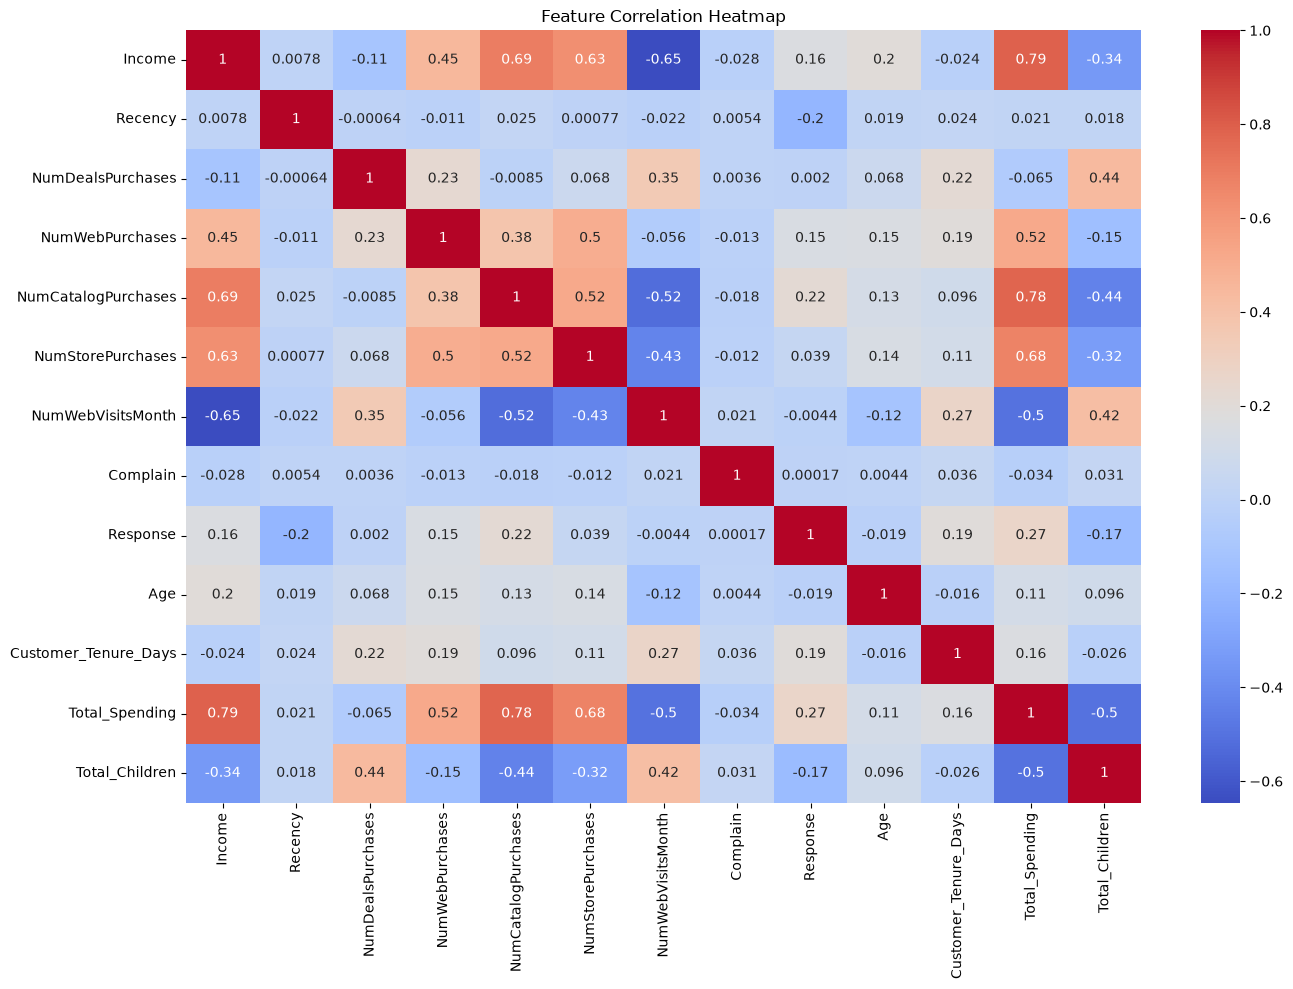

In [23]:
# Correlation Heatmap

corr_matrix = df_clean.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [24]:
# PCA — 2D Visualization

pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print(f"Variance captured by PC1: {pca_2d.explained_variance_ratio_[0]:.4f}")
print(f"Variance captured by PC2: {pca_2d.explained_variance_ratio_[1]:.4f}")
print(f"Total variance (2 components): {sum(pca_2d.explained_variance_ratio_):.4f}")

Variance captured by PC1: 0.2316
Variance captured by PC2: 0.1139
Total variance (2 components): 0.3455


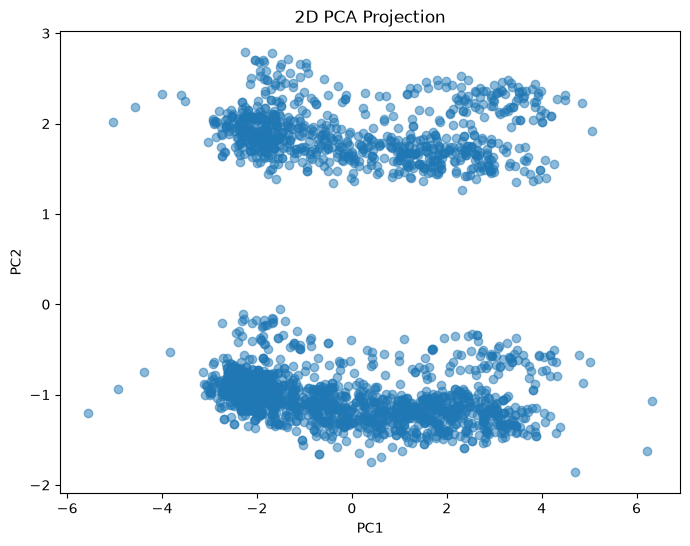

In [25]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Projection")
plt.show()

In [26]:
# PCA — 3D Visualization

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

print(f"Total variance (3 components): {sum(pca_3d.explained_variance_ratio_):.4f}")

Total variance (3 components): 0.4495


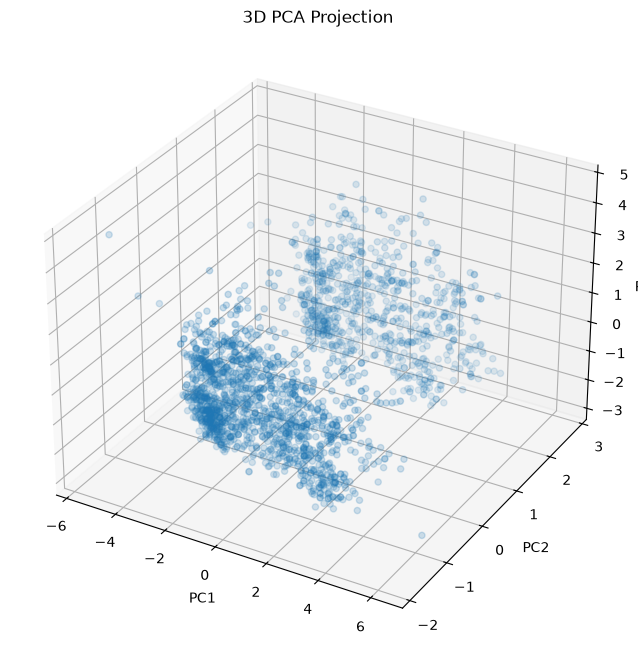

In [27]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], alpha=0.5)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA Projection")
plt.show()

## 9. Saving Processed Data

In [28]:
# PCA data (3 components) for clustering
pca_df = pd.DataFrame(X_pca_3d, columns=["PC1", "PC2", "PC3"])
pca_df.to_csv("../datasets/processed_pca.csv", index=False)

# Encoded features (unscaled) for cluster characterization
df_encoded.to_csv("../datasets/processed_features.csv", index=False)